# Lab: DBSCAN and HDBSCAN Clustering

*In this lab, we will build **DBSCAN** and **HDBSCAN** clustering models using scikit-learn and compare them with the K-Means results from the previous lab. This project builds upon the [K-Means Clustering Lab](./04_k-means_clustering_lab.ipynb), reusing the same ShopSmart Mall customer dataset to demonstrate how different clustering algorithms can reveal different insights from the same data.*

---

> ### 📝 1. Business Understanding Report (Summary)
> - **Business Context:** This project continues the customer segmentation initiative for "ShopSmart Mall" from the [K-Means Clustering Lab](./04_k-means_clustering_lab.ipynb). The previous analysis successfully identified 6 customer segments using K-Means clustering. However, the marketing team has requested an alternative analysis to validate the segmentation results and explore whether different clustering approaches might reveal additional or different patterns in customer behavior.
> - **Business Problem:** While K-Means assumes spherical clusters and requires specifying the number of clusters in advance, the marketing team wants to explore whether the customer base contains clusters of arbitrary shapes or outliers that K-Means might have missed. Additionally, they want to understand if some customers don't naturally fit into any segment (potential outliers) and whether the density of customer groupings varies across different behavioral patterns.
> - **Project Goal:** To apply density-based clustering algorithms (DBSCAN and HDBSCAN) to the same customer dataset and compare the results with K-Means. The aim is to:
>   1. Discover customer segments based on density rather than distance to centroids
>   2. Automatically identify outlier customers who don't fit well into any segment
>   3. Validate the K-Means segmentation by comparing with density-based approaches
>   4. Provide the marketing team with insights on which clustering approach better captures the natural structure of their customer base

---

> ### 📝 2. Analytic Approach Report (Summary)
> - **Problem Type:** *Unsupervised Learning - Clustering*, with a focus on density-based approaches that can discover arbitrary-shaped clusters and automatically identify noise points (outliers).
> - **Model Selection:** We will implement and compare two density-based clustering algorithms:
>   - **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** A classic density-based algorithm that groups together points that are closely packed, marking points in low-density regions as outliers. DBSCAN requires two parameters: epsilon (ε, neighborhood radius) and minimum points (min_samples).
>   - **HDBSCAN (Hierarchical DBSCAN):** An extension of DBSCAN that builds a hierarchy of clusters and extracts stable clusters across varying densities. HDBSCAN requires fewer parameters (primarily min_cluster_size) and is more robust to clusters with varying densities.
> - **Comparison with K-Means:** Unlike K-Means (which assumes spherical clusters and requires specifying k), DBSCAN and HDBSCAN can:
>   - Discover clusters of arbitrary shapes
>   - Automatically determine the number of clusters
>   - Identify noise points (outliers) that don't belong to any cluster
>   - Handle clusters with varying densities (HDBSCAN particularly excels at this)
> - **Evaluation Metrics:**
>     - **Silhouette Score:** Measure cluster cohesion and separation (same as K-Means for consistency)
>     - **Number of Clusters Found:** Compare with K-Means' predetermined k=6
>     - **Number of Noise Points:** Identify customers who don't fit well into any segment
>     - **Visual Inspection:** 2D/3D scatter plots to assess cluster quality and outlier detection
>     - **Comparison with K-Means Results:** Analyze how many customers are assigned to similar vs. different groups
>     - **Business Interpretation:** Evaluate whether density-based segments are more or less actionable than K-Means segments
> - ⚠️ **Note:** This lab focuses on comparing different clustering paradigms (centroid-based vs. density-based) on the same real-world dataset to understand their respective strengths and trade-offs.

---

> ### 📝 3. Data Requirements Report (Summary)
> - **Data Source:** This project reuses the cleaned and prepared dataset from the [K-Means Clustering Lab](./04_k-means_clustering_lab.ipynb), specifically the `mall_customers_interim_v1.parquet` file stored in `../data/interim/`.
> - **Features (Customer Characteristics):**
>     - `customer_id`: Unique identifier for each customer
>     - `age`: Age of the customer (in years)
>     - `gender`: Gender of the customer (categorical: Male/Female)
>     - `annual_income`: Annual income of the customer (in thousands of dollars)
>     - `spending_score`: A score assigned based on customer behavior and spending patterns (scale: 1-100)
> - **Data Preparation Status:** The dataset has already undergone:
>   - Column name standardization (snake_case convention)
>   - Duplicate removal and quality validation
>   - No missing values detected
>   - All data types are appropriate for analysis
> - **Modeling Features:** We will use the same three features as the K-Means lab for direct comparison:
>   - `age`, `annual_income`, `spending_score` (all will be standardized)
> - **Target/Outcome:** There is no target variable. The clustering algorithms will discover groupings based on the natural density patterns in the feature space.
> - **Data Reusability:** By using the same prepared dataset, we ensure a fair, apples-to-apples comparison between K-Means and density-based clustering approaches.

---

## Stage 4: Data Collection
Since this project builds upon the K-Means lab, we'll load the previously prepared dataset and reuse the standardization artifacts.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import joblib
from pathlib import Path

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import hdbscan

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

In [ ]:
# Load the interim dataset from K-Means lab
interim_data_path = Path("../data/interim/mall_customers_interim_v1.parquet")
mall_df = pd.read_parquet(interim_data_path)

print(f"Loaded dataset with {mall_df.shape[0]} samples and {mall_df.shape[1]} features:")
display(mall_df.head())

Loaded dataset with 200 samples and 5 features:


,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



---

> ### 📝 4. Data Collection Report (Summary)
> **Data Reuse:** Successfully loaded the mall_customers_interim_v1.parquet dataset from the K-Means lab, containing 200 customer samples with 5 features (customer_id, gender, age, annual_income, spending_score).

---

## Stage 5: Data Understanding
Since we're reusing the same dataset from the K-Means lab, we'll skip the comprehensive EDA and instead focus on visualizing the data to understand its density characteristics—critical for DBSCAN and HDBSCAN.

### 5.1. Quick Data Overview

In [8]:
# Load the feature names from K-Means lab
model_dir = Path("../models")
feature_names_path = model_dir / "feature_names_mall_customers.joblib"
feature_names = joblib.load(feature_names_path)

# Verify data structure
print("Dataset info:")
print(f"  - Samples: {mall_df.shape[0]}")
print(f"  - Features: {feature_names}")
print(f"  - No missing values: {mall_df[feature_names].isnull().sum().sum() == 0}")

# Summary statistics
print("\nSummary statistics:")
display(mall_df[feature_names].describe().T)

Dataset info:
  - Samples: 200
  - Features: ['age', 'annual_income', 'spending_score']
  - No missing values: True

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
annual_income,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
spending_score,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


### 5.2. Visualize Data Density Patterns

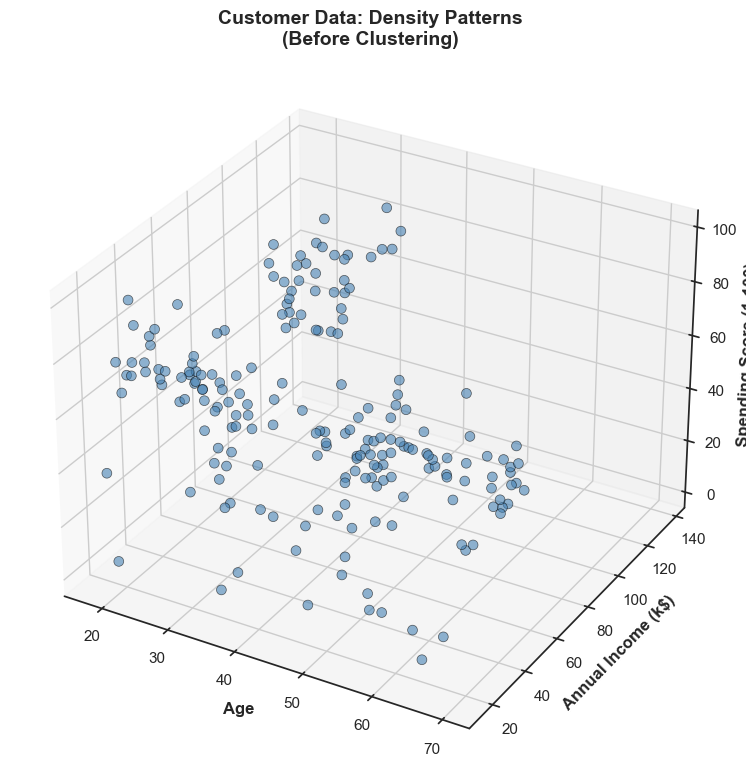

In [9]:
# 3D scatter plot to visualize natural density groupings
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    mall_df['age'],
    mall_df['annual_income'],
    mall_df['spending_score'],
    c='steelblue',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax.set_title("Customer Data: Density Patterns\n(Before Clustering)", fontweight="bold", fontsize=14)
ax.set_xlabel("Age", fontweight="bold")
ax.set_ylabel("Annual Income (k$)", fontweight="bold")
ax.set_zlabel("Spending Score (1-100)", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3. Pairwise Relationships for Density Assessment

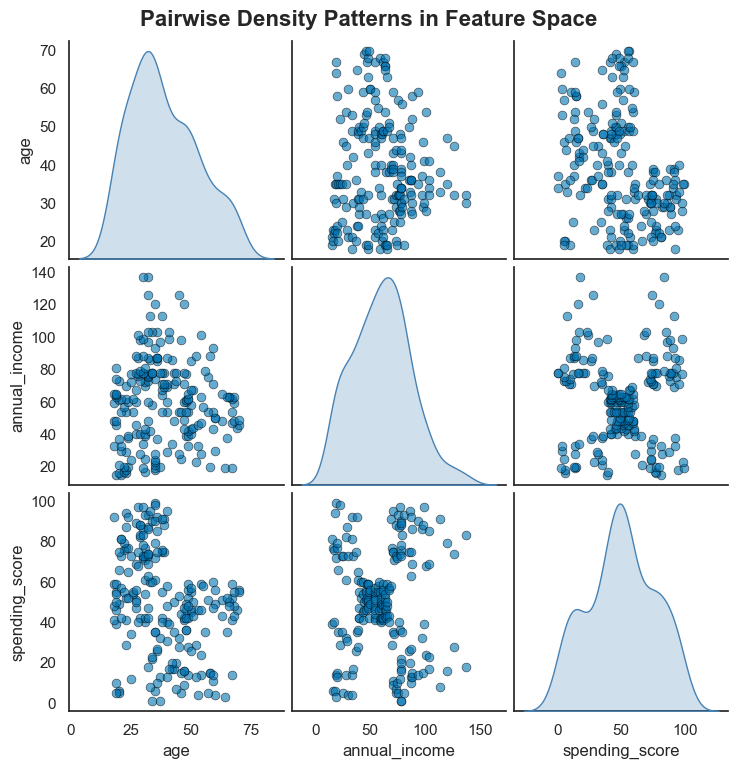

In [10]:
# Pairplot to assess density patterns in 2D projections
pairplot = sns.pairplot(
    data=mall_df[feature_names],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'black', 'linewidth': 0.5},
    diag_kws={'color': 'steelblue'}
)
pairplot.figure.suptitle("Pairwise Density Patterns in Feature Space", fontsize=16, fontweight="bold", y=1.02)
plt.show()


---

> ### 📝 5. Data Understanding Report (Summary)
> * **Data Overview:** Dataset contains 200 customer samples with three numerical features (age, annual_income, spending_score) and no missing values—identical to the K-Means lab baseline.
> * **Density Patterns Observed:**
>   - Visual inspection of 3D scatter plots reveals potential dense regions in the feature space, particularly in the annual_income vs. spending_score plane
>   - Some customers appear relatively isolated (potential outliers), especially at the extremes of income and spending ranges
>   - Density appears to vary across different regions—some areas show tight groupings while others are more sparse
> * **Suitability for Density-Based Clustering:**
>   - ✅ The data exhibits varying local densities, which is ideal for DBSCAN/HDBSCAN (they can adapt to density variations)
>   - ✅ Potential outliers are visible, allowing density-based algorithms to identify customers who don't fit well into segments
>   - ✅ Unlike K-Means which assumes uniform density, DBSCAN/HDBSCAN can discover clusters of different densities
> * **Key Insight:** The visual density patterns suggest that density-based clustering may identify segments different from K-Means, particularly by separating outliers and recognizing non-spherical groupings.
> * **Comparison Note:** While K-Means found 6 spherical clusters with similar densities, DBSCAN/HDBSCAN may discover a different number of clusters based on actual density patterns and explicitly identify noise points.

---

## Stage 6: Data Preparation
Since we're reusing the standardized data from the K-Means lab, minimal preparation is needed. However, we'll verify the data is ready for density-based clustering.

In [11]:
# Load the scaler from K-Means lab
scaler_path = model_dir / "scaler_mall_customers.joblib"
scaler = joblib.load(scaler_path)

# Extract features and apply standardization
X = mall_df[feature_names].copy()
X_scaled = scaler.transform(X)  # Use transform (not fit_transform) - scaler already fitted

# Convert to DataFrame for interpretability
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[f'{name}_scaled' for name in feature_names],
    index=X.index
)

print(f"Standardized feature matrix shape: {X_scaled.shape}")
print("\nFirst 5 rows of standardized features:")
display(X_scaled_df.head())

Standardized feature matrix shape: (200, 3)

First 5 rows of standardized features:


,age_scaled,annual_income_scaled,spending_score_scaled
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [13]:
# Confirm standardized features are ready
print("Feature matrix ready for density-based clustering:")
print(f"  - Shape: {X_scaled.shape}")
print(f"  - Features: {feature_names}")
print("  - Standardized: Mean ≈ 0, Std ≈ 1")
print("\nFeature means (should be ~0):")
print(X_scaled.mean(axis=0))
print("\nFeature standard deviations (should be ~1):")
print(X_scaled.std(axis=0))

Feature matrix ready for density-based clustering:
  - Shape: (200, 3)
  - Features: ['age', 'annual_income', 'spending_score']
  - Standardized: Mean ≈ 0, Std ≈ 1

Feature means (should be ~0):
[-1.02140518e-16 -2.13162821e-16 -1.46549439e-16]

Feature standard deviations (should be ~1):
[1. 1. 1.]



---

> ### 📝 6. Data Preparation Report (Summary)
> * **Data Status:** The standardized feature matrix X_scaled is fully prepared and requires no additional preprocessing.
> * **Standardization Verification:** Confirmed that all features have mean ≈ 0 and standard deviation ≈ 1, ensuring distance-based calculations in DBSCAN are not dominated by features with larger scales.
> * **Key Differences from K-Means Preparation:**
>   * No need to specify number of clusters (k) in advance—DBSCAN/HDBSCAN determine this automatically
>   * No random initialization concerns—DBSCAN/HDBSCAN are deterministic given their parameters
>   * No need for multiple runs—results are reproducible without random_state variations
> * **Parameter Selection Strategy:** Unlike K-Means' Elbow Method for choosing k, DBSCAN requires selecting:
>   * **eps (ε):** Maximum distance for neighborhood—will use k-distance plot method
>   * **min_samples:** Minimum points to form dense region—will test values based on dimensionality (d=3, so min_samples ≥ 4)
> * **HDBSCAN Advantage:** HDBSCAN requires primarily min_cluster_size, reducing parameter sensitivity compared to DBSCAN.
> * **Output:** Standardized feature matrix X_scaled with shape (200, 3) is ready for modeling.

---

## Stage 7: Modeling